## **Polynomial Logistic Regression**

### **Topic Roadmap**

**1. Environment Setup and Data Loading**

**2. Baseline: Linear Decision Boundary**

**3. Polynomial Feature Transformation**

**4. Visualizing Complex Decision Boundaries**

### **1. Environment Setup and Data Loading**

Import standard libraries and configure visualization settings. A synthetic non-linear dataset is generated to simulate real-world data requiring non-linear classification boundaries.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures

sns.set_theme(style="whitegrid")

In [2]:
# Generate a non-linear dataset (U-shape/Moon-shape) for classification
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

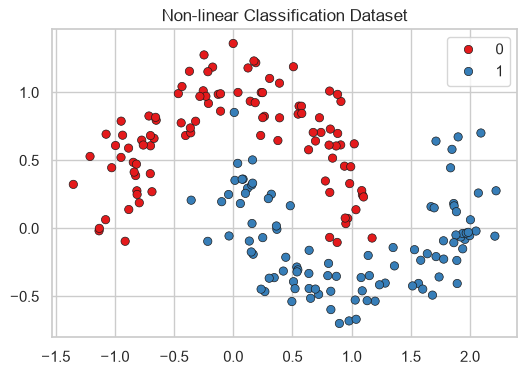

In [3]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k")
plt.title("Non-linear Classification Dataset")
plt.show()

### **2. Baseline: Linear Decision Boundary**

Train a standard Logistic Regression model. Standard Logistic Regression can only draw a straight line (hyperplane) to separate classes, which inherently underfits non-linear data.

In [4]:
baseline_clf = LogisticRegression()
baseline_clf.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
# Evaluate using 10-fold cross-validation
cv_accuracy = np.mean(cross_val_score(baseline_clf, X, y, scoring='accuracy', cv=10))
print(f"Baseline Linear Accuracy: {cv_accuracy:.4f}")

Baseline Linear Accuracy: 0.8500


### **3. Polynomial Feature Transformation**

To capture non-linear relationships, features are expanded into a polynomial space. For example, a 2D input $(x_1, x_2)$ transformed with `degree=2` becomes $(x_1, x_2, x_1^2, x_1 x_2, x_2^2)$.

In [6]:
# Transform features to a higher-dimensional space (Degree 3)
poly_transformer = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_transformer.fit_transform(X)

In [7]:
poly_clf = LogisticRegression(max_iter=1000)
poly_clf.fit(X_poly, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
poly_cv_accuracy = np.mean(cross_val_score(poly_clf, X_poly, y, scoring='accuracy', cv=10))
print(f"Polynomial (Degree 3) Accuracy: {poly_cv_accuracy:.4f}")

Polynomial (Degree 3) Accuracy: 0.9450


### **4. Visualizing Complex Decision Boundaries**

Defining a robust visualization function to observe how increasing the polynomial degree changes the classification boundary. 
*Note: `max_iter` is increased to prevent `ConvergenceWarning` at high polynomial degrees.*

In [9]:
def plot_decision_boundary(X_data, y_data, degree=1):
    """
    Transforms data to a polynomial degree, fits a Logistic Regression model,
    and visualizes the resulting decision boundary.
    """
    # Pipeline simulation
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_trf = poly.fit_transform(X_data)
    
    clf = LogisticRegression(max_iter=10000) # Prevents convergence warnings
    clf.fit(X_trf, y_data)
    
    accuracy = np.mean(cross_val_score(clf, X_trf, y_data, scoring='accuracy', cv=10))
    
    # Create a mesh grid
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    # Predict across the grid
    grid_input = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(poly.transform(grid_input))
    Z = Z.reshape(xx.shape)
    
    # Plotting
    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    sns.scatterplot(x=X_data[:, 0], y=X_data[:, 1], hue=y_data, palette='Set1', edgecolor='k', legend=False)
    plt.title(f'Degree = {degree} | CV Accuracy = {accuracy:.4f}')
    plt.show()

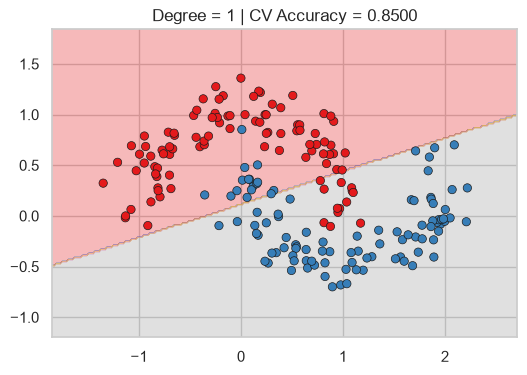

In [10]:
# Underfitting: Standard Linear Boundary
plot_decision_boundary(X, y, degree=1)

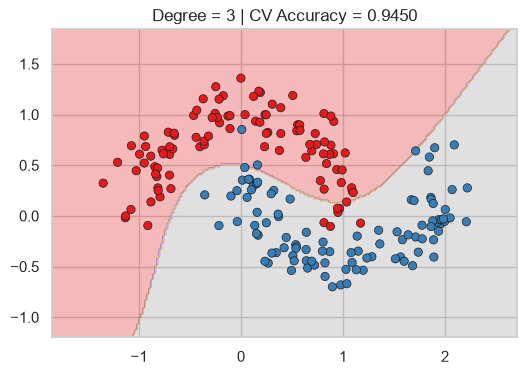

In [11]:
# Good Fit: Polynomial Boundary accurately captures the data curvature
plot_decision_boundary(X, y, degree=3)

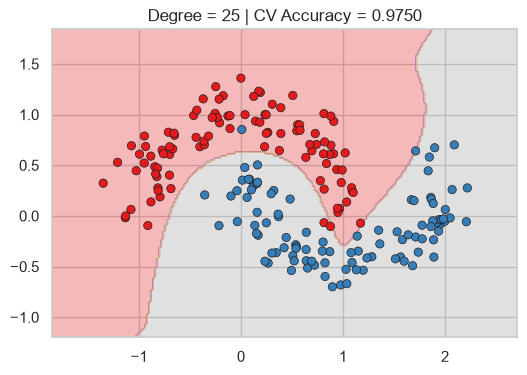

In [12]:
# Overfitting: Highly complex boundary memorizing noise in the training set
plot_decision_boundary(X, y, degree=25)

### **Key Revision Notes**

- **Polynomial Expansion:** Logistic Regression remains a *linear model* mathematically. It applies a linear boundary in the new, higher-dimensional polynomial space, which projects back down as a curved boundary in the original 2D space.
- **Degree 1:** Equivalent to standard Logistic Regression. Underfits complex data structures.
- **Optimal Degree (e.g., Degree 3-5):** Captures the underlying data distribution, maximizing Cross-Validation Accuracy.
- **High Degree (e.g., Degree 25):** Severe Overfitting. The boundary warps to encompass individual noise points. Without increasing `max_iter` or applying strict $L2$ regularization (`C` parameter), optimization fails to converge efficiently due to multi-collinearity and extreme values generated by $x^{25}$.